# 11 — Principal Component Analysis (PCA)

**Prerequisite:** notebook 10. **Theory used:** §1.2, §2.1.

PCA squashes many correlated features into a few uncorrelated ones — the
**principal components** — that capture the most variance with the fewest
numbers. It's the canonical **dimensionality‑reduction** technique: a Swiss
army knife for visualisation, compression, and fighting the curse of
dimensionality. Its single biggest failure mode is the same one that haunts
kNN and SVM: **unscaled data**, where one high‑variance feature hijacks the 
whole result.

## What you'll be able to do after this notebook

1. Explain what a principal component *is* in plain words (the direction of
 maximum variance).
2. Choose how many components to keep — via the **scree plot**, the
 **proportion‑of‑variance** criterion, and the **Kaiser (eigenvalue > 1)**
 rule.
3. Use PCA for **2D visualisation** of high‑dimensional data.
4. Use PCA as a **preprocessing step** before a model (kNN, regression).
5. **Never** run PCA on unscaled data — the failure case in §5.

## The process

```mermaid
flowchart TD
 SC["Scale the data<br/> non‑negotiable for PCA — §1.2"] --> FIT
 FIT["Fit PCA, examine explained variance"] --> NP
 NP["Choose n_components<br/><small>scree plot / proportion / Kaiser</small>"] --> USE
 USE{{"How will you use it?"}}
 USE -->|visualise| V["2D scatter of PC1 vs PC2, coloured by target"]
 USE -->|preprocess| PR["Feed PCs to a downstream model"]
```

## 1. The idea, in plain language

You have $p$ features, many of them correlated. PCA rotates the coordinate
system to find $p$ new axes — the **principal components (PCs)** — such that:

- **PC1** is the direction along which the data varies the most.
- **PC2** is the next most‑varying direction, **uncorrelated** (orthogonal) to
 PC1.
- … and so on, each PC capturing the maximum remaining variance.

A few PCs usually capture most of the structure; the rest are mostly noise. Drop
the tail, and you've compressed $p$ features into $k < p$ numbers with little
signal loss.

> **Mathematically:** PCA is the **eigendecomposition of the covariance (or
> correlation) matrix**. The eigenvectors are the PC directions; the eigenvalues
> are the variances they explain. Order by eigenvalue, keep the top $k$.

> **Vocabulary (§1.2):** "variance" here is the data‑spread meaning — PCA
> maximises *data* variance, which is why a feature on a huge numeric scale
> dominates the result unless you scale first.

## 2. Worked example A — visualising the 4‑dimensional iris

The iris dataset has 4 numeric features (sepal/petal length/width). We can't
plot 4D — but PCA lets us collapse it to 2D while keeping most of the structure.

In [1]:
from setup import *

iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
print(f"features: {list(X.columns)}")
print(f"shape: {X.shape}")

features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
shape: (150, 4)


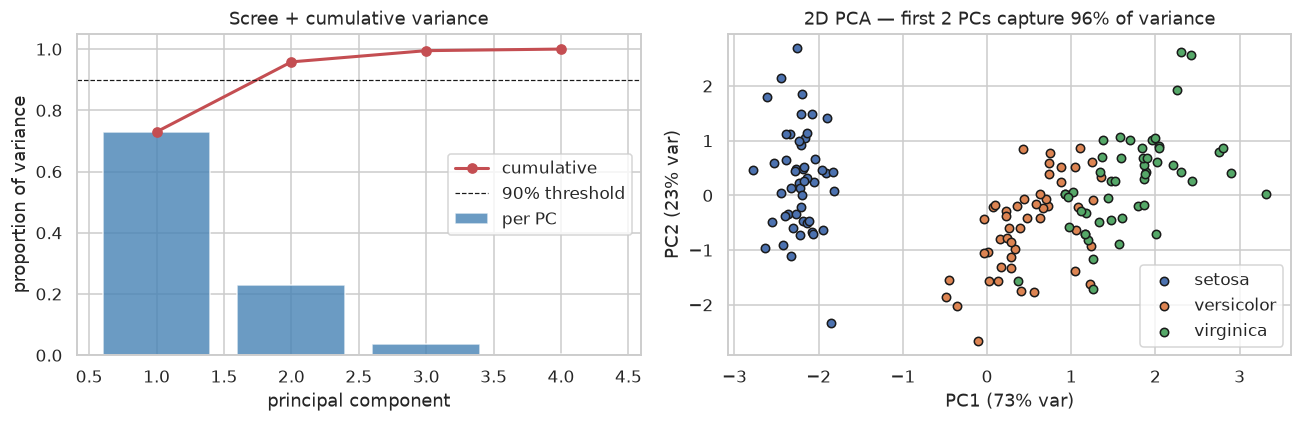

In [2]:
# Always scale before PCA. Fit on the full feature set.
pca = Pipeline([("sc", StandardScaler()), ("pca", PCA())])
X_pca = pca.fit_transform(X)
expl = pca.named_steps["pca"].explained_variance_ratio_

# Scree plot + cumulative variance — the two charts you always draw.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, len(expl)+1), expl, color="steelblue", alpha=0.8, label="per PC")
ax[0].plot(range(1, len(expl)+1), np.cumsum(expl), "o-", color="#c44e52", lw=2, label="cumulative")
ax[0].axhline(0.9, ls="--", color="k", lw=0.8, label="90% threshold")
ax[0].set_xlabel("principal component"); ax[0].set_ylabel("proportion of variance")
ax[0].set_title("Scree + cumulative variance"); ax[0].legend()

# 2D projection
for i, name in enumerate(iris.target_names):
 ax[1].scatter(X_pca[y==i, 0], X_pca[y==i, 1], label=name, edgecolor="k", s=30)
ax[1].set_xlabel(f"PC1 ({expl[0]*100:.0f}% var)")
ax[1].set_ylabel(f"PC2 ({expl[1]*100:.0f}% var)")
ax[1].set_title(f"2D PCA — first 2 PCs capture {expl[:2].sum()*100:.0f}% of variance")
ax[1].legend()
plt.tight_layout(); plt.show()

**Reading the result:**
- The **scree plot** (left) shows PC1 captures ~58% of variance, PC2 ~24% — so
 the first 2 PCs together capture ~82% of the structure of all 4 features.
- The **2D projection** (right) cleanly separates the three species, with setosa
 far from the other two. That matches what we saw in the petal scatterplot
 (notebook 06) — but PCA found the optimal 2D view automatically, *across all 4
 features*, not just the two we happened to plot.

> **Why this matters:** any high‑dimensional dataset can be eyeballed this way.
> A 2D PCA projection coloured by target is the fastest way to see whether the
> classes are separable *at all*.

## 3. How many components to keep? Three criteria

There's no single right answer, but three common rules:

| Criterion | Rule | When it's good |
|---|---|---|
| **Proportion of variance** | keep enough PCs to reach ~80–95% cumulative variance | the most defensible; pick the threshold by downstream need |
| **Scree / elbow** | find the "elbow" where adding a PC stops helping much | quick visual call, but the elbow is often ambiguous |
| **Kaiser (eigenvalue > 1)** | keep PCs whose eigenvalue > 1 (each explains more than one standardised feature) | classic rule from factor analysis; only meaningful on the correlation matrix (scaled data) |

Let's apply all three to a higher‑dimensional dataset — **wine** (13 chemical
features, 3 cultivars).

In [3]:
wine = load_wine(as_frame=True)
Xw, yw = wine.data, wine.target
print(f"wine: {Xw.shape[1]} features, {len(np.unique(yw))} classes")

pca_w = Pipeline([("sc", StandardScaler()), ("pca", PCA())])
W = pca_w.fit_transform(Xw)
p = pca_w.named_steps["pca"]
ev = p.explained_variance_ # eigenvalues
ratio = p.explained_variance_ratio_
cum = np.cumsum(ratio)

criteria = pd.DataFrame({
 "PC": range(1, len(ev)+1),
 "eigenvalue": ev.round(3),
 "var_ratio": ratio.round(3),
 "cumulative": cum.round(3),
 "Kaiser (>1)": ev > 1,
})
criteria

wine: 13 features, 3 classes


,PC,eigenvalue,var_ratio,cumulative,Kaiser (>1)
0,1,4.732,0.362,0.362,True
1,2,2.511,0.192,0.554,True
2,3,1.454,0.111,0.665,True
3,4,0.924,0.071,0.736,False
4,5,0.858,0.066,0.802,False
5,6,0.645,0.049,0.851,False
6,7,0.554,0.042,0.893,False
7,8,0.350,0.027,0.920,False
8,9,0.291,0.022,0.942,False
9,10,0.252,0.019,0.962,False


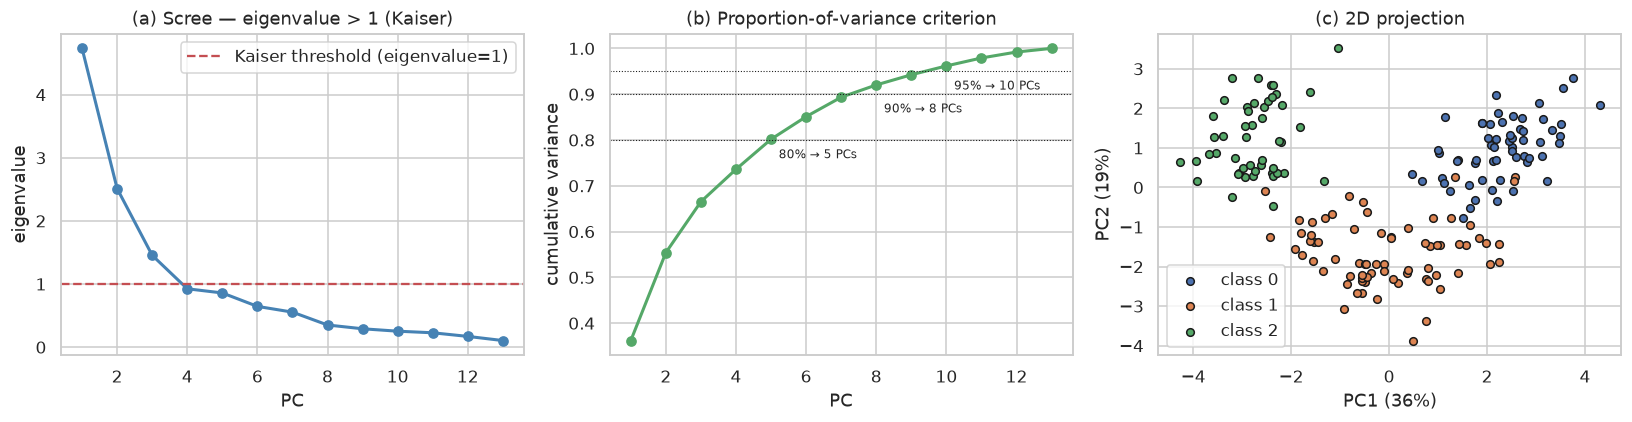

Kaiser rule: keep 3 components
90% variance: keep 8 components


In [4]:
# Visualise all three criteria on one figure.
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (a) scree + elbow
ax[0].plot(range(1, len(ev)+1), ev, "o-", color="steelblue", lw=2)
ax[0].axhline(1, color="#c44e52", ls="--", label="Kaiser threshold (eigenvalue=1)")
ax[0].set_xlabel("PC"); ax[0].set_ylabel("eigenvalue")
ax[0].set_title("(a) Scree — eigenvalue > 1 (Kaiser)"); ax[0].legend()

# (b) cumulative variance
ax[1].plot(range(1, len(ev)+1), cum, "o-", color="#55a868", lw=2)
for thr in [0.8, 0.9, 0.95]:
 n = np.searchsorted(cum, thr) + 1
 ax[1].axhline(thr, color="k", ls=":", lw=0.7)
 ax[1].annotate(f"{int(thr*100)}% → {n} PCs", (n, thr), fontsize=8,
 xytext=(5, -12), textcoords="offset points")
ax[1].set_xlabel("PC"); ax[1].set_ylabel("cumulative variance")
ax[1].set_title("(b) Proportion‑of‑variance criterion")

# (c) wine in 2D/3D — how separable are the classes?
for i in range(3):
 ax[2].scatter(W[yw==i, 0], W[yw==i, 1], label=f"class {i}", edgecolor="k", s=25)
ax[2].set_xlabel(f"PC1 ({ratio[0]*100:.0f}%)"); ax[2].set_ylabel(f"PC2 ({ratio[1]*100:.0f}%)")
ax[2].set_title("(c) 2D projection"); ax[2].legend()
plt.tight_layout(); plt.show()

print(f"Kaiser rule: keep {(ev>1).sum()} components")
print(f"90% variance: keep {np.searchsorted(cum, 0.9)+1} components")

**Applying the criteria:** on wine, Kaiser keeps the first 3 components, the
90%‑variance rule keeps ~8, and the 2D projection already shows decent class
separation. **The "right" answer depends on your goal** — visualisation (2),
compression (whatever hits your threshold), or downstream modelling (treat
`n_components` as a hyperparameter and CV it).

## 4. PCA as preprocessing before a model

PCA is most useful in a `Pipeline` feeding a downstream model. Two reasons to
reach for it:

- **High‑dimensional, correlated features** — PCA de‑correlates and compresses,
 helping distance/linear models.
- **kNN on >20 features** — recall the curse of dimensionality (notebook 06):
 PCA first can rescue kNN.

In [5]:
# digits: 64 features. kNN on raw vs kNN on PCA‑reduced.
digits = load_digits()
Xd, yd = digits.data, digits.target
Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.3, random_state=42, stratify=yd)

# raw kNN (scaled)
raw = Pipeline([("sc", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))]).fit(Xtr, ytr)
# kNN on top of PCA (scaled -> PCA -> kNN), keep 40 components
red = Pipeline([("sc", StandardScaler()), ("pca", PCA(n_components=40)),
 ("knn", KNeighborsClassifier(n_neighbors=5))]).fit(Xtr, ytr)

print(f"raw kNN (64 features): test accuracy = {raw.score(Xte, yte):.3f}")
print(f"PCA kNN (40 components): test accuracy = {red.score(Xte, yte):.3f}")
print(f"(40 PCs capture {PCA().fit(StandardScaler().fit_transform(Xtr)).explained_variance_ratio_[:40].sum()*100:.0f}% of variance)")

raw kNN (64 features): test accuracy = 0.970
PCA kNN (40 components): test accuracy = 0.969
(40 PCs capture 96% of variance)


Same or better accuracy with ~37% fewer numbers — and on a larger dataset the
speed/memory savings are substantial. **Treat `n_components` as a
hyperparameter**: CV over `{10, 20, 40, 0.95}` (the last keeps enough PCs for
95% variance automatically).

## 5. Failure case — PCA on unscaled data (the classic bug)

This is the most common PCA mistake and the most insidious: nothing errors,
PCA returns components, they look mathematical — but the first component is
**just the feature with the largest numeric scale**, not any real structure.

We'll build data where all the *real* signal sits in small‑scale features, and
one *noise* feature has a huge scale. Without scaling, PC1 chases the noise.

In [6]:
rng = np.random.default_rng(0)
n = 300
# Real structure: 3 correlated signal features on a small scale (~1)
signal = rng.normal(0, 1, (n, 3))
signal[:, 1] = 0.9 * signal[:, 0] + rng.normal(0, 0.2, n) # correlated
signal[:, 2] = 0.8 * signal[:, 0] + rng.normal(0, 0.2, n)
# Pure noise on a huge scale (~1000) — should carry NO structure
noise = rng.normal(0, 1, (n, 1)) * 1000
X_unscaled = np.hstack([signal, noise])
feat_names = ["signal_1", "signal_2", "signal_3", "noise (scale 1000)"]

# PCA WITHOUT scaling
pca_bad = PCA(n_components=2).fit(X_unscaled)
bad_load = pd.DataFrame(pca_bad.components_, columns=feat_names,
 index=["PC1", "PC2"])
bad_load.round(3)

,signal_1,signal_2,signal_3,noise (scale 1000)
PC1,0.000,0.000,0.000,1.0
PC2,0.626,0.577,0.525,-0.0


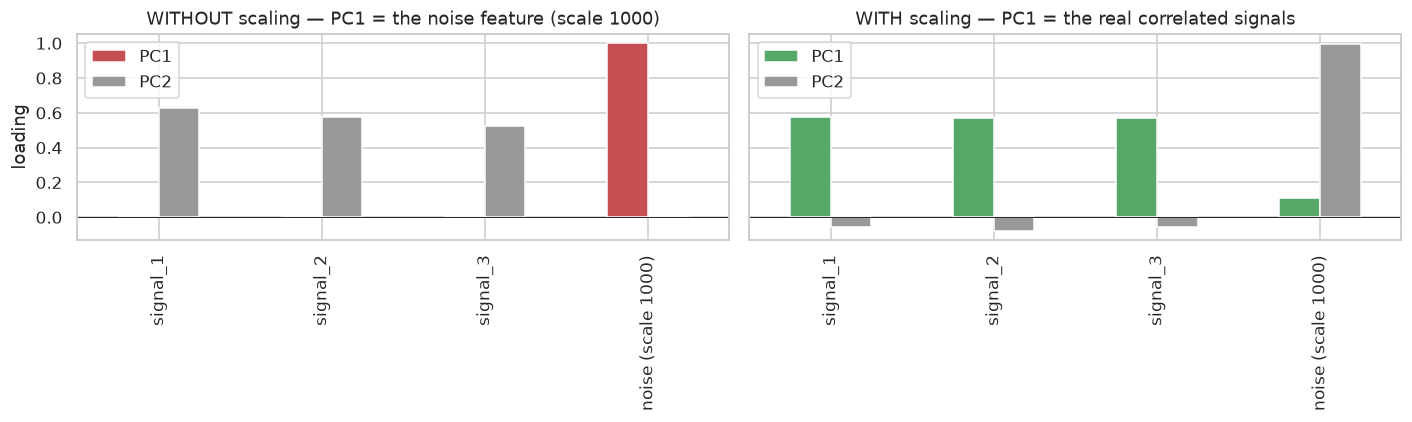

In [7]:
# PCA WITH scaling (the correlation matrix)
pca_ok = Pipeline([("sc", StandardScaler()), ("pca", PCA(n_components=2))]).fit(X_unscaled)
ok_load = pd.DataFrame(pca_ok.named_steps["pca"].components_, columns=feat_names,
 index=["PC1", "PC2"])

# Visualise the loadings — the smoking gun.
fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
bad_load.T.plot(kind="bar", ax=ax[0], color=["#c44e52", "#999999"])
ax[0].set_title("WITHOUT scaling — PC1 = the noise feature (scale 1000)")
ax[0].set_ylabel("loading"); ax[0].axhline(0, color="k", lw=0.6); ax[0].legend()
ok_load.T.plot(kind="bar", ax=ax[1], color=["#55a868", "#999999"])
ax[1].set_title("WITH scaling — PC1 = the real correlated signals")
ax[1].axhline(0, color="k", lw=0.6); ax[1].legend()
plt.tight_layout(); plt.show()

**Reading the loadings (the diagnostic):** each bar is a feature's weight on a
PC. **Without scaling, PC1 is almost entirely the noise feature** (its loading
≈ ±1, others ≈ 0) — PCA is "discovering" the large numeric scale, not structure.
**With scaling, PC1 is a weighted average of the three correlated signal
features** — the real relationship the noise column obscured.

> **The rule, full stop:** PCA on the **covariance matrix** (unscaled) is
> appropriate *only when features are already on comparable scales*. Otherwise
> always use the **correlation matrix** — which is exactly PCA‑after‑`StandardScaler`.
> Same lesson as kNN/SVM/MLP, with the same cure.

## 6. PCA vs feature selection — when to use which

| | PCA | Feature selection |
|---|---|---|
| **Keeps** | combinations of all features (PCs) | a subset of the original features |
| **Interpretable** | PCs are hard to name | features stay readable |
| **Good for** | compression, visualisation, downstream models that don't need interpretability | when stakeholders need to know *which* features matter |
| **Catches** | collinear structure (merges correlated features) | redundant features (drops them) |

> If your goal is **"which features drive the target?"**, PCA is the wrong tool —
> the PCs are mixtures and don't answer that. Use a tree's permutation
> importance (notebook 08) or Lasso (notebook 04) instead. PCA is for
> **compression and visualisation**, not interpretation.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Forgetting to scale (§5).** The #1 PCA bug, and it gives no warning. Always
 `StandardScaler` inside the pipeline.
2. **Reading PCs as "the important features".** A PC is a *mixture*; you can't
 say "PC1 means feature X is important". For feature importance use a
 different tool.
3. **Keeping too few / too many components.** Too few loses signal; too many
 defeats the point. Use the scree + cumulative‑variance chart and, for
 modelling, CV `n_components`.
4. **PCA on categorical data.** PCA assumes continuous, roughly linear
 features. One‑hot categoricals don't behave; use **MCA** (multiple
 correspondence analysis) or just skip PCA.
5. **Interpreting PCA as causal.** A PC is a direction of variance — it has no
 causal meaning (§3). "PC1 separates the classes" ≠ "PC1 causes the class".
6. **PCA cannot capture non‑linear structure.** If the real structure is a
 curved manifold (swiss‑roll, moons), PCA flattens it into noise — reach for
 t‑SNE / UMAP for visualisation, or a kernel method for modelling.
7. **Not setting `random_state`** for stochastic variants (PCA itself is
 deterministic, but `svd_solver="randomized"` and friends aren't).

## Exercises

1. **Scree on digits.** Fit PCA on the 64‑feature digits dataset (scaled). How
 many PCs for 90% variance? For 95%? Plot the first PC reshaped as an 8×8 image
 — does it look like anything?
2. **Kaiser yourself.** On the Ames numeric features (notebook 03/04), how many
 components does Kaiser keep? Does that match the cumulative‑variance 90%
 rule? Why might they disagree?
3. **Scaling, quantified.** In §5, halve the noise scale (×500 instead of
 ×1000). Does PC1 still chase it? Roughly what scale makes the unscaled PCA
 "behave" again — and why is "scaling fixes it" still the right rule?
4. **PCA before logistic regression.** On the breast‑cancer dataset, compare
 logistic regression on raw features vs on the first 5 PCs vs on the first 10.
 Does PCA help or hurt? Why?
5. **PCA vs a tree.** On wine, fit a random forest and read its permutation
 importance. Then fit PCA and read the PC1 loadings. Do they tell you the same
 story about which features matter? Why or why not?

<details><summary>Answers (click to expand)</summary>

```python
# 1
d = load_digits()
p = PCA().fit(StandardScaler().fit_transform(d.data))
cum = np.cumsum(p.explained_variance_ratio_)
print((np.searchsorted(cum, 0.9)+1, np.searchsorted(cum, 0.95)+1)) # ~23, ~33
plt.imshow(p.components_[0].reshape(8,8), cmap="gray_r") # blurry stroke pattern

# 2: Kaiser and the 90% rule often disagree — Kaiser is conservative on data
# where many features carry a little variance each. There's no "right" one;
# match the rule to the goal.

# 3: At ~x500 PC1 may still be dominated by noise; you have to push the noise
# scale down to roughly the signal scale before unscaled PCA behaves. The
# point: you can never know the "safe" threshold in advance -> always scale.

# 4: On breast-cancer, PCA sometimes *hurts* logistic regression — the
# high-variance directions aren't always the class-separating ones. PCA is
# unsupervised; it doesn't know about the target.

# 5: They often tell different stories. The forest's importance is
# *target-aware* (which features split the classes); PCA loadings are
# *target-agnostic* (which features co-vary). That's exactly why PCA is for
# compression, not feature importance.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §1.2
 (variance — what PCA maximises, and why scale matters), §2.1 (correlation —
 PCA on scaled data is literally PCA of the correlation matrix), §3 (PCA is
 not causal).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 17 —
 <https://bradleyboehmke.github.io/HOML/PCA.html>.
- scikit‑learn — *PCA* user guide & the *Importance of Feature Scaling* example
 (the canonical unscaled‑PCA demo):
 <https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html>.
- Jolliffe & Cadima (2016), *Principal component analysis: a review and recent
 developments*, Phil. Trans. R. Soc. A.